<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/combined_cnn_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Models for Annihilation Position Reconstruction


- **1 — Deterministic CNN** : plane-feature model that directly regresses the annihilation position (X, Y, Z).
- **2 — Probabilistic CNN** :  trained with a Gaussian negative-log-likelihood loss so it predicts a mean position and a per-axis uncertainty, plus a physics-informed projection of the prediction onto the detector-hit plane.

.



## 0. Shared setup



In [1]:
%pip install uproot
%pip install awkward_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 51.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())

branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
]

df = tree.arrays(branches, library="pd")
df.head()

def get_axis_ranges(df):
    """Min/max extent of the detector hits, used to fix the histogram
    binning so every event image lines up on the same grid."""

    xmin, xmax = df.X_mm.min(), df.X_mm.max()
    ymin, ymax = df.Y_mm.min(), df.Y_mm.max()
    zmin, zmax = df.Z_mm.min(), df.Z_mm.max()

    return xmin, xmax, ymin, ymax, zmin, zmax


def build_images_targets_planes(df, xmin, xmax, ymin, ymax, zmin, zmax, img_size=64):
    """Turn each 3-gamma event into:

    - a (img_size, img_size, 3) "image" whose channels are the energy-weighted
      XY, XZ and YZ projections of the three detector hits
    - a regression target: the true annihilation position (X, Y, Z)
    - a plane feature [A, B, C, D] describing the plane through the three
      detector hits (Ax + By + Cz + D = 0), used as auxiliary input to the CNN

    Events that don't have exactly 3 hits, or whose hits are collinear
    (degenerate plane), are skipped.
    """

    images, targets, plane_features = [], [], []

    event_groups = df.groupby(["RunID", "EventID"], sort=False)
    print(f"Building images from {event_groups.ngroups} events...")

    for i, ((run_id, event_id), event) in enumerate(event_groups):

        points = event.sort_values("GammaIndex")[["X_mm", "Y_mm", "Z_mm"]].values
        if len(points) != 3:
            continue

        P1, P2, P3 = points

        # Plane through the three detector hits
        v1, v2 = P2 - P1, P3 - P1
        normal = np.cross(v1, v2)

        if np.linalg.norm(normal) == 0:
            continue

        normal = normal / np.linalg.norm(normal)
        A, B, C = normal
        D = -np.dot(normal, P1)
        plane_features.append([A, B, C, D])

        # Energy-weighted 2D projections as image channels
        image = np.zeros((img_size, img_size, 3), dtype=np.float32)

        H_xy, _, _ = np.histogram2d(
            event["X_mm"], event["Y_mm"],
            bins=img_size, range=[[xmin, xmax], [ymin, ymax]],
            weights=event["EnergyDeposit_keV"],
        )
        image[:, :, 0] = H_xy

        H_xz, _, _ = np.histogram2d(
            event["X_mm"], event["Z_mm"],
            bins=img_size, range=[[xmin, xmax], [zmin, zmax]],
            weights=event["EnergyDeposit_keV"],
        )
        image[:, :, 1] = H_xz

        H_yz, _, _ = np.histogram2d(
            event["Y_mm"], event["Z_mm"],
            bins=img_size, range=[[ymin, ymax], [zmin, zmax]],
            weights=event["EnergyDeposit_keV"],
        )
        image[:, :, 2] = H_yz

        images.append(image)
        targets.append([
            event["AnnihilX_mm"].iloc[0],
            event["AnnihilY_mm"].iloc[0],
            event["AnnihilZ_mm"].iloc[0],
        ])

        if (i + 1) % 1000 == 0:
            print(f"{i + 1} events processed")

    images = np.array(images, dtype=np.float16)
    targets = np.array(targets, dtype=np.float32)
    plane_features = np.array(plane_features, dtype=np.float32)

    print()
    print("Images shape :", images.shape)
    print("Targets shape:", targets.shape)
    print("Plane features shape:", plane_features.shape)

    return images, targets, plane_features


def build_cnn_backbone(image_input):
    """Three conv+pool blocks shared by both models, turning the detector
    image into a flat feature vector."""

    x = Conv2D(16, (3, 3), activation="relu")(image_input)
    x = MaxPooling2D()(x)

    x = Conv2D(32, (3, 3), activation="relu")(x)
    x = MaxPooling2D()(x)

    x = Conv2D(64, (3, 3), activation="relu")(x)
    x = MaxPooling2D()(x)

    return Flatten()(x)


def build_plane_branch(plane_input, units=16):
    """Small dense branch that embeds the plane-equation features so they
    can be concatenated with the CNN's image features."""

    return Dense(units, activation="relu")(plane_input)

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


---
## 1 Deterministic CNN (direct X, Y, Z regression)

This model takes the detector image and the plane features and directly regresses the annihilation position. It's trained with plain MSE loss and benchmarked against a naive baseline (always predicting the mean training position).

### 1.1 Build detector images and regression targets

In [5]:
IMG_SIZE = 64

xmin_DE, xmax_DE, ymin_DE, ymax_DE, zmin_DE, zmax_DE = get_axis_ranges(df)
print(xmin_DE, xmax_DE)
print(ymin_DE, ymax_DE)
print(zmin_DE, zmax_DE)

images_DE, targets_DE, plane_features_DE = build_images_targets_planes(
    df, xmin_DE, xmax_DE, ymin_DE, ymax_DE, zmin_DE, zmax_DE , img_size=IMG_SIZE
)

-99.15685272216797 95.1434555053711
-92.13552856445312 96.26758575439453
-95.55072784423828 98.47635650634766
Building images from 18591 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed

Images shape : (18591, 64, 64, 3)
Targets shape: (18591, 3)
Plane features shape: (18591, 4)


In [6]:
# Normalise images to [0, 1]
images_DE = images_DE / np.max(images_DE)

print(images_DE.min(), images_DE.max())

0.0 1.0


### 1.2 Train / test split

In [7]:
x_train_DE, x_test_DE, plane_train_DE, plane_test_DE, y_train_DE, y_test_DE = train_test_split(
    images_DE,
    plane_features_DE,
    targets_DE,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print("Training images :", x_train_DE.shape)
print("Training planes :", plane_train_DE.shape)
print("Training targets:", y_train_DE.shape)
print("Test images     :", x_test_DE.shape)
print("Test planes     :", plane_test_DE.shape)
print("Test targets    :", y_test_DE.shape)

Training images : (14872, 64, 64, 3)
Training planes : (14872, 4)
Training targets: (14872, 3)
Test images     : (3719, 64, 64, 3)
Test planes     : (3719, 4)
Test targets    : (3719, 3)


### 1.3 Scale targets

In [8]:
target_scaler_DE = StandardScaler()

y_train_scaled_DE = target_scaler_DE.fit_transform(y_train_DE)
y_test_scaled_DE = target_scaler_DE.transform(y_test_DE)

print(y_train_scaled_DE[0])

[ 0.920658  -0.8802103 -1.9163066]


### 1.4 Build the model

In [9]:
image_input_DE = Input(shape=(64, 64, 3), name="image_input")
x_DE = build_cnn_backbone(image_input_DE)

plane_input_DE = Input(shape=(4,), name="plane_input")
plane_branch_DE = build_plane_branch(plane_input_DE)

combined_DE = Concatenate()([x_DE, plane_branch_DE])
combined_DE = Dense(128, activation="relu")(combined_DE)
combined_DE = Dropout(0.3)(combined_DE)

# Deterministic regression output: (x, y, z)
output_DE = Dense(3, name="xyz")(combined_DE)

model_DE = Model(inputs=[image_input_DE, plane_input_DE], outputs=output_DE)
model_DE.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_input         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2304)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         80 │ plane_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2320)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    297,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xyz (Dense)         │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,139 (1.23 MB)

 Trainable params: 321,139 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

### 1.5 Compile & train

In [10]:
model_DE.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

history_A = model_DE.fit(
    [x_train_DE, plane_train_DE],
    y_train_scaled_DE,
    validation_split=0.2,
    epochs=40,
    batch_size=8,
    callbacks=[early_stop],
)

Epoch 1/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.8894 - mae: 0.7818 - val_loss: 0.7688 - val_mae: 0.7180
Epoch 2/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.7175 - mae: 0.6832 - val_loss: 0.6559 - val_mae: 0.6507
Epoch 3/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6618 - mae: 0.6527 - val_loss: 0.6458 - val_mae: 0.6433
Epoch 4/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.6385 - mae: 0.6403 - val_loss: 0.6113 - val_mae: 0.6269
Epoch 5/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6171 - mae: 0.6288 - val_loss: 0.6030 - val_mae: 0.6206
Epoch 6/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6033 - mae: 0.6217 - val_loss: 0.5957 - val_mae: 0.6168
Epoch 7/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.5835 - mae: 0.6107 - val_loss: 0.6025 - val_mae: 0.6189
Epoch 8/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.5698 - mae: 0.6027 - val_loss: 0.5919 - val_mae: 0.6146
Epoch 9/40
1488/1488 ━━━━━━━━━━━━━━━━━

### 1.6 Training curves

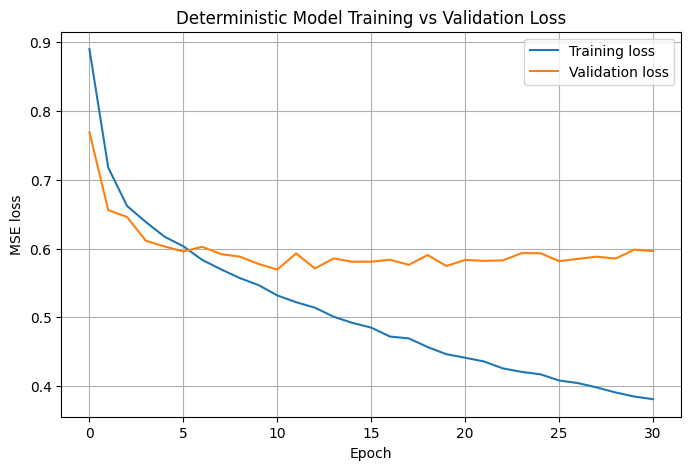

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history_A.history["loss"], label="Training loss")
plt.plot(history_A.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Deterministic Model Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

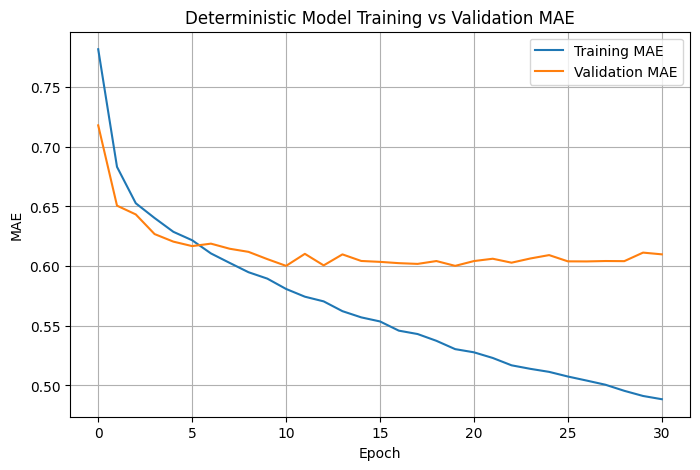

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_A.history["mae"], label="Training MAE")
plt.plot(history_A.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Deterministic Model Training vs Validation MAE")
plt.legend()
plt.grid()
plt.show()

### 1.7 Predictions vs. a naive baseline

In [14]:
prediction_scaled_DE = model_DE.predict([x_test_DE, plane_test_DE])
prediction_DE = target_scaler_DE.inverse_transform(prediction_scaled_DE)

for i in range(5):
    print("True:     ", y_test_DE[i])
    print("Predicted:", prediction_DE[i])
    print()

117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
True:      [  5.387624    -0.08580948 -10.092469  ]
Predicted: [ 2.9993517  2.8973799 -8.745832 ]

True:      [ 4.315522   1.6260263 -7.961517 ]
Predicted: [ 2.0325174  1.6182348 -9.263719 ]

True:      [ 3.8994508  3.005647  -8.104934 ]
Predicted: [ 2.0816748  2.63975   -7.5724807]

True:      [ 2.7971644  6.0933194 -7.1500335]
Predicted: [ 0.84740645  2.517028   -7.831845  ]

True:      [ 1.5251509   0.22125395 -8.647183  ]
Predicted: [ 1.6190835   0.21287361 -8.835321  ]



In [15]:
position_error_DE = prediction_DE - y_test_DE

distance_error_DE = np.sqrt(np.sum(position_error_DE ** 2, axis=1))

print("Mean annihilation position error:", np.mean(distance_error_DE), "mm")
print("Median annihilation position error:", np.median(distance_error_DE), "mm")

Mean annihilation position error: 2.5720503 mm
Median annihilation position error: 2.4237566 mm


In [18]:
# Naive baseline: always predict the mean training position
mean_position_DE = np.mean(y_train_DE, axis=0)
baseline_prediction_DE = np.tile(mean_position_DE, (len(y_test_DE), 1))

baseline_mse_DE = mean_squared_error(y_test_DE, baseline_prediction_DE)
cnn_mse_DE = mean_squared_error(y_test_DE, prediction_DE)

baseline_mae_DE = mean_absolute_error(y_test_DE, baseline_prediction_DE)
cnn_mae_DE = mean_absolute_error(y_test_DE, prediction_DE)

print("Baseline MSE:", baseline_mse_DE, " | CNN MSE:", cnn_mse_DE)
print("Baseline MAE:", baseline_mae_DE, " | CNN MAE:", cnn_mae_DE)
print ('Overall Improvement', (baseline_mae_DE - cnn_mae_DE) / baseline_mae_DE * 100, '%')
print("\nPer-axis MAE (baseline vs CNN):")
for i, coord in enumerate(["X", "Y", "Z"]):
    baseline_i = mean_absolute_error(y_test_DE[:, i], baseline_prediction_DE[:, i])
    cnn_i = mean_absolute_error(y_test_DE[:, i], prediction_DE[:, i])
    print(f"  {coord}: baseline={baseline_i:.2f} mm, CNN={cnn_i:.2f} mm")

r2_overall_DE = r2_score(y_test_DE, prediction_DE)
r2_axes_DE = [r2_score(y_test_DE[:, i], prediction_DE[:, i]) for i in range(3)]

print("\nOverall R2:", r2_overall_DE)
print("Per-axis R2 (X, Y, Z):", r2_axes_DE)

Baseline MSE: 4.758697032928467  | CNN MSE: 2.668358564376831
Baseline MAE: 1.818593144416809  | CNN MAE: 1.283167839050293
Overall Improvement 29.441731209110966 %

Per-axis MAE (baseline vs CNN):
  X: baseline=1.68 mm, CNN=1.20 mm
  Y: baseline=2.27 mm, CNN=1.54 mm
  Z: baseline=1.51 mm, CNN=1.11 mm

Overall R2: 0.43579769134521484
Per-axis R2 (X, Y, Z): [0.416273832321167, 0.45288097858428955, 0.438237726688385]


### 1.8 Reconstruction, distributions and residuals

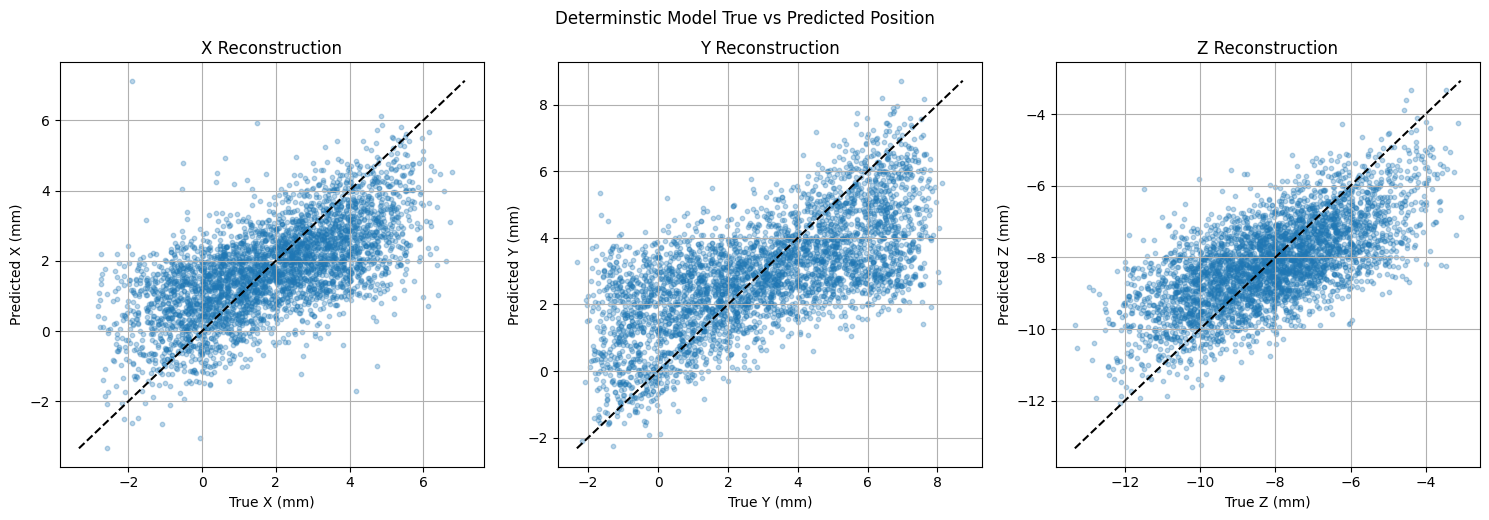

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):
    ax.scatter(y_test_DE[:, i], prediction_DE[:, i], alpha=0.3, s=10)
    lo = min(y_test_DE[:, i].min(), prediction_DE[:, i].min())
    hi = max(y_test_DE[:, i].max(), prediction_DE[:, i].max())
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel(f"Predicted {coords[i]} (mm)")
    ax.set_title(f"{coords[i]} Reconstruction")
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Determinstic Model True vs Predicted Position", y=1.03)
plt.show()

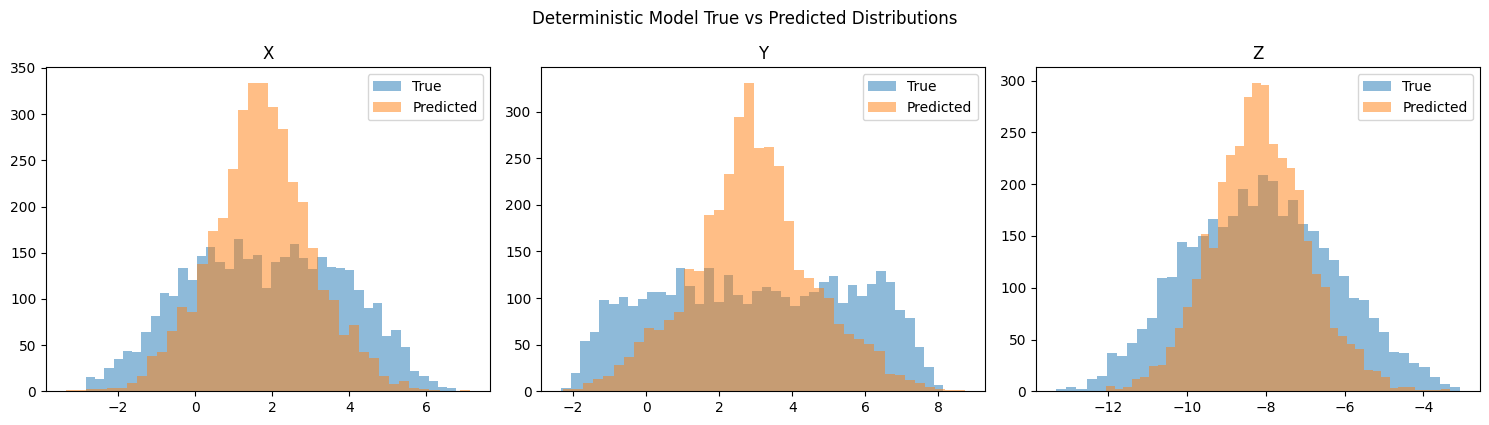

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    ax.hist(y_test_DE[:, i], bins=40, alpha=0.5, label="True")
    ax.hist(prediction_DE[:, i], bins=40, alpha=0.5, label="Predicted")
    ax.set_title(coords[i])
    ax.legend()

plt.tight_layout()
plt.suptitle("Deterministic Model True vs Predicted Distributions", y=1.05)
plt.show()

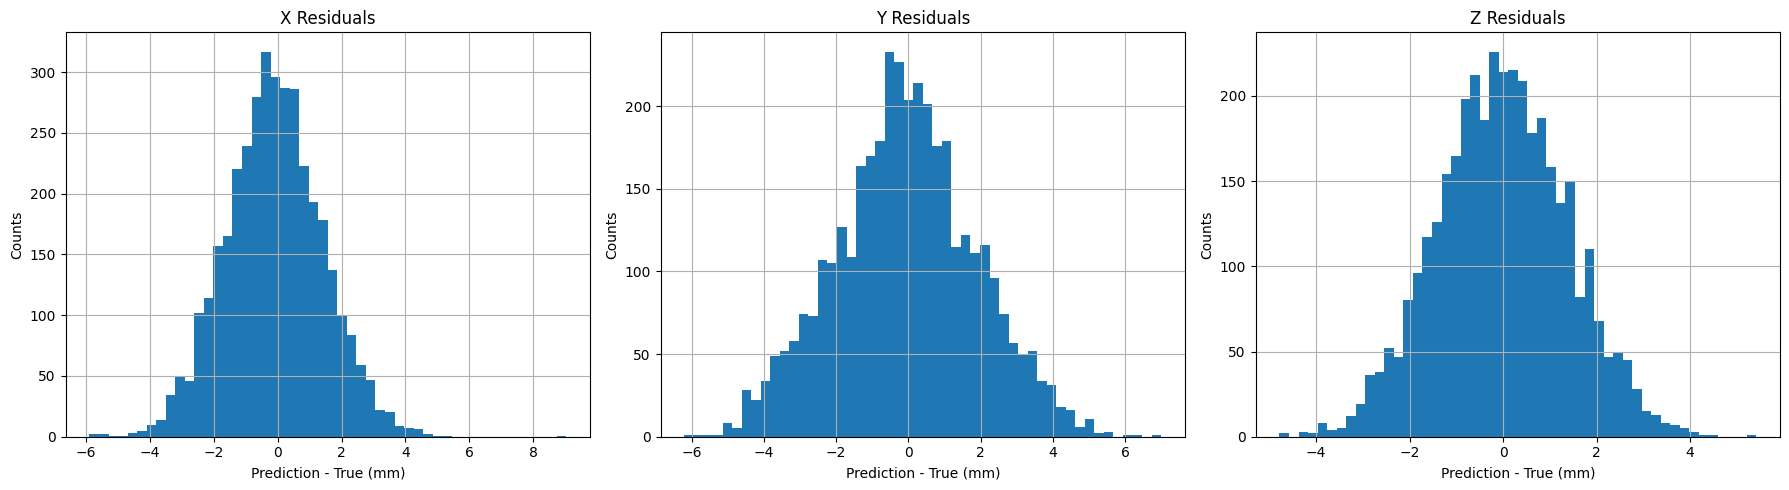

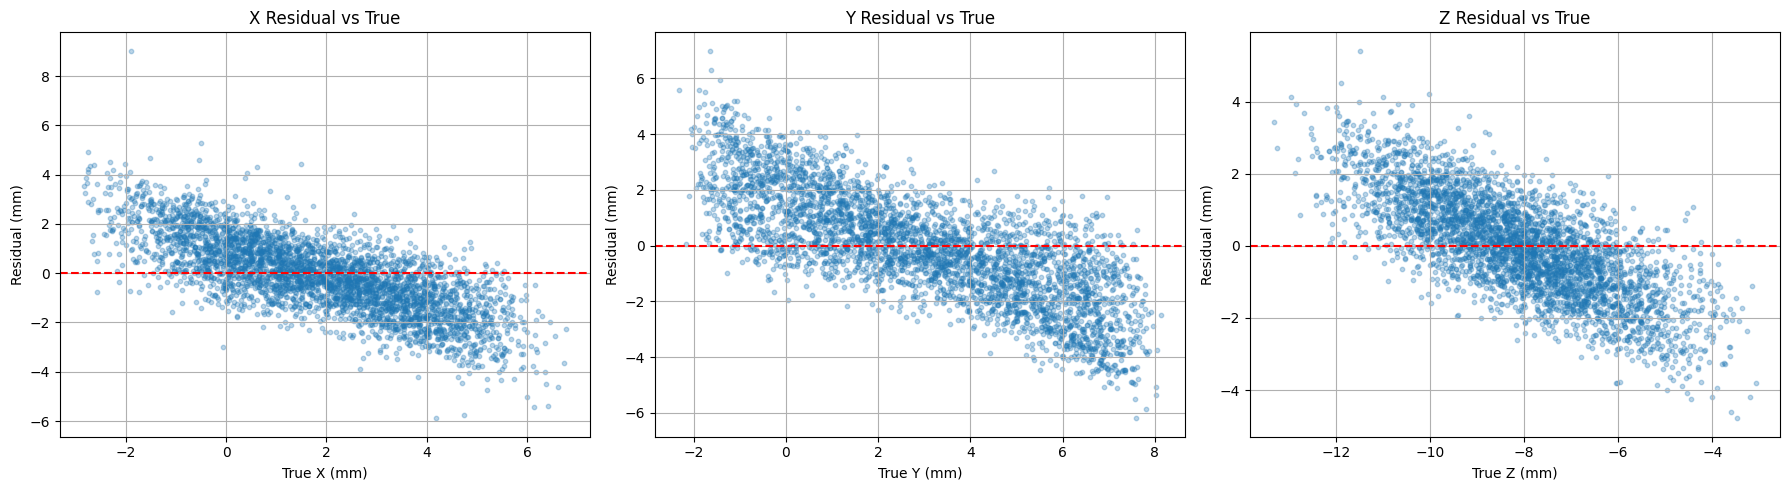

X
  Mean residual: -0.10 mm
  Std residual : 1.52 mm
  MAE          : 1.20 mm

Y
  Mean residual: -0.07 mm
  Std residual : 1.94 mm
  MAE          : 1.54 mm

Z
  Mean residual: -0.01 mm
  Std residual : 1.39 mm
  MAE          : 1.11 mm



In [22]:
residuals_DE = prediction_DE - y_test_DE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.hist(residuals_DE[:, i], bins=50)
    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction - True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.scatter(y_test_DE[:, i], residuals_DE[:, i], alpha=0.3, s=10)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel("Residual (mm)")
    ax.set_title(f"{coords[i]} Residual vs True")
    ax.grid(True)
plt.tight_layout()
plt.show()

for i, coord in enumerate(coords):
    print(coord)
    print(f"  Mean residual: {np.mean(residuals_DE[:, i]):.2f} mm")
    print(f"  Std residual : {np.std(residuals_DE[:, i]):.2f} mm")
    print(f"  MAE          : {np.mean(np.abs(residuals_DE[:, i])):.2f} mm")
    print()

### 1.9 Summary

In [29]:
results_DE = {
    "model": "Model A (Deterministic CNN)",
    "mae_x": mean_absolute_error(y_test_DE[:, 0], prediction_DE[:, 0]),
    "mae_y": mean_absolute_error(y_test_DE[:, 1], prediction_DE[:, 1]),
    "mae_z": mean_absolute_error(y_test_DE[:, 2], prediction_DE[:, 2]),
    "mae_overall": cnn_mae_DE,
    "mean_3d_error_mm": np.mean(distance_error_DE),
    "median_3d_error_mm": np.median(distance_error_DE),
    "r2_overall": r2_overall_DE,
    "r2_x": r2_axes_DE[0],
    "r2_y": r2_axes_DE[1],
    "r2_z": r2_axes_DE[2],
    'improvement over naive baseline (%)': (baseline_mae_DE - cnn_mae_DE) / baseline_mae_DE * 100,
}

print(results_DE)

{'model': 'Model A (Deterministic CNN)', 'mae_x': 1.2001675367355347, 'mae_y': 1.5397486686706543, 'mae_z': 1.109588861465454, 'mae_overall': 1.283167839050293, 'mean_3d_error_mm': np.float32(2.5720503), 'median_3d_error_mm': np.float32(2.4237566), 'r2_overall': 0.43579769134521484, 'r2_x': 0.416273832321167, 'r2_y': 0.45288097858428955, 'r2_z': 0.438237726688385, 'improvement over naive baseline (%)': 29.441731209110966}


---
## 2.Probabilistic CNN



###2.1 Build detector images and regression targets

In [55]:
xmin_PR, xmax_PR, ymin_PR, ymax_PR, zmin_PR, zmax_PR = get_axis_ranges(df)
print(xmin_PR, xmax_PR)
print(ymin_PR, ymax_PR)
print(zmin_PR, zmax_PR)

images_PR, targets_PR, plane_features_PR = build_images_targets_planes(
    df, xmin_PR, xmax_PR, ymin_PR, ymax_PR, zmin_PR, zmax_PR, img_size=IMG_SIZE
)

-99.15685272216797 95.1434555053711
-92.13552856445312 96.26758575439453
-95.55072784423828 98.47635650634766
Building images from 18591 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed

Images shape : (18591, 64, 64, 3)
Targets shape: (18591, 3)
Plane features shape: (18591, 4)


In [56]:
images_PR = images_PR / np.max(images_PR)

print(images_PR.min(), images_PR.max())

0.0 1.0


### 2.2 Train / validation / test split


In [57]:
x_train_PR, x_temp_PR, y_train_PR, y_temp_PR, plane_train_PR, plane_temp_PR = train_test_split(
    images_PR,
    targets_PR,
    plane_features_PR,
    test_size=0.3,
    random_state=42,
    shuffle=True,
)

x_val_PR, x_test_PR, y_val_PR, y_test_PR, plane_val_PR, plane_test_PR = train_test_split(
    x_temp_PR,
    y_temp_PR,
    plane_temp_PR,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

print("Train:", x_train_PR.shape, y_train_PR.shape, plane_train_PR.shape)
print("Val:  ", x_val_PR.shape, y_val_PR.shape, plane_val_PR.shape)
print("Test: ", x_test_PR.shape, y_test_PR.shape, plane_test_PR.shape)

Train: (13013, 64, 64, 3) (13013, 3) (13013, 4)
Val:   (2789, 64, 64, 3) (2789, 3) (2789, 4)
Test:  (2789, 64, 64, 3) (2789, 3) (2789, 4)


### 2.3 Scale targets

In [58]:
target_scaler_PR = StandardScaler()

y_train_scaled_PR = target_scaler_PR.fit_transform(y_train_PR)
y_val_scaled_PR = target_scaler_PR.transform(y_val_PR)
y_test_scaled_PR = target_scaler_PR.transform(y_test_PR)

print(y_train_scaled_PR[0])

[-0.18592414  1.2884794  -0.5519326 ]


### 2.4 Build the probabilistic model

In [59]:
image_input_PR = Input(shape=(64, 64, 3), name="detector_image")
x_PR = build_cnn_backbone(image_input_PR)

plane_input_PR = Input(shape=(4,), name="plane_equation")
plane_branch_PR = build_plane_branch(plane_input_PR)

combined_PR = Concatenate()([x_PR, plane_branch_PR])
combined_PR = Dense(128, activation="relu")(combined_PR)
combined_PR = Dropout(0.3)(combined_PR)

# Probabilistic output: [mu_x, mu_y, mu_z, raw_sigma_x, raw_sigma_y, raw_sigma_z]
output_PR = Dense(6, name="mu_and_raw_sigma")(combined_PR)

model_PR = Model(inputs=[image_input_PR, plane_input_PR], outputs=output_PR)
model_PR.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ detector_image      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 62, 62,    │        448 │ detector_image[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 31, 31,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 6, 6, 64)  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_equation      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │         80 │ plane_equation[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 2320)      │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │    297,088 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu_and_raw_sigma    │ (None, 6)         │        774 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,526 (1.23 MB)

 Trainable params: 321,526 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

###2.5 Gaussian negative log-likelihood loss

In [60]:
def gaussian_nll(y_true, y_pred):
    """Negative log-likelihood of the true position under a diagonal
    Gaussian with mean `mu` and standard deviation `sigma`, both predicted
    by the network (in scaled target units)."""

    mu = y_pred[:, :3]
    raw_sigma = y_pred[:, 3:]

    # softplus keeps sigma positive and numerically stable
    sigma = tf.nn.softplus(raw_sigma) + 1e-6

    nll = 0.5 * tf.square((y_true - mu) / sigma) + tf.math.log(sigma)

    return tf.reduce_mean(nll)

### 2.6 Compile & train

In [61]:
model_PR.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=gaussian_nll,
)

history_PR = model_PR.fit(
    [x_train_PR, plane_train_PR],
    y_train_scaled_PR,
    validation_data=([x_val_PR, plane_val_PR], y_val_scaled_PR),
    epochs=50,
    batch_size=32,
)

Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - loss: 0.4977 - val_loss: 0.4642
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 0.4639 - val_loss: 0.4449
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4386 - val_loss: 0.4175
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4077 - val_loss: 0.3858
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3778 - val_loss: 0.3586
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3506 - val_loss: 0.3425
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3274 - val_loss: 0.3197
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3123 - val_loss: 0.3056
Epoch 9/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2955 - val_loss: 0.2884
Epoch 10/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2790 - val_loss: 0.2806
Epoch 11/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2652 - val_loss: 0.2697
Epoch 12/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms

### 1.7 Training curve

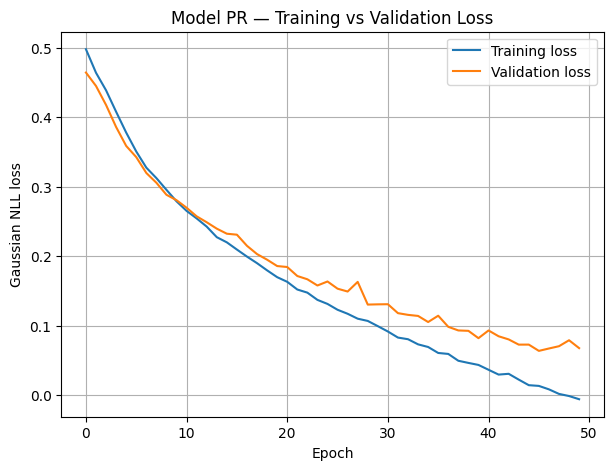

In [62]:
plt.figure(figsize=(7, 5))
plt.plot(history_PR.history["loss"], label="Training loss")
plt.plot(history_PR.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Gaussian NLL loss")
plt.title("Model PR — Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

### 1.8 Predictions: mean, uncertainty, and plane projection

In [63]:
raw_prediction_PR = model_PR.predict([x_test_PR, plane_test_PR])

mu_scaled_PR = raw_prediction_PR[:, :3]
sigma_scaled_PR = tf.nn.softplus(raw_prediction_PR[:, 3:]).numpy() + 1e-6

# Undo target scaling: for a StandardScaler, std_original = std_scaled * scale_
mu_mm_PR = target_scaler_PR.inverse_transform(mu_scaled_PR)
sigma_mm_PR = sigma_scaled_PR * target_scaler_PR.scale_

print("mu_mm shape:", mu_mm_PR.shape)
print("sigma_mm shape:", sigma_mm_PR.shape)

for i in range(5):
    print("Event", i)
    print("  True:       ", y_test_PR[i])
    print("  Predicted:  ", mu_mm_PR[i])
    print("  Uncertainty:", sigma_mm_PR[i])
    print()

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
mu_mm shape: (2789, 3)
sigma_mm shape: (2789, 3)
Event 0
  True:        [  4.9761834   0.3410897 -10.657421 ]
  Predicted:   [ 2.4986832  3.2185097 -8.467263 ]
  Uncertainty: [1.24500643 1.48064856 1.27095369]

Event 1
  True:        [ 4.6802645  5.131514  -9.532785 ]
  Predicted:   [ 2.8617883  3.470043  -9.466152 ]
  Uncertainty: [1.44273964 2.14482585 1.23478882]

Event 2
  True:        [ 0.9647649  2.1288269 -6.3443527]
  Predicted:   [ 0.05207802  1.4492596  -6.667197  ]
  Uncertainty: [0.99170478 1.5348515  1.07938627]

Event 3
  True:        [ 1.3216504  6.7202992 -4.0047636]
  Predicted:   [ 0.5613345  6.4213915 -5.211922 ]
  Uncertainty: [1.3127203  1.24728525 1.02913574]

Event 4
  True:        [ 2.5921383  2.2871537 -8.874028 ]
  Predicted:   [ 3.1722286  3.1306117 -8.785411 ]
  Uncertainty: [1.25538555 2.26221553 1.13320925]



In [64]:
# Project the predicted mean onto the plane defined by the 3 detector hits
normal_PR = plane_test_PR[:, :3]
D_PR = plane_test_PR[:, 3]

signed_distance_PR = np.sum(normal_PR * mu_mm_PR, axis=1) + D_PR
mu_mm_PR_projected = mu_mm_PR - signed_distance_PR[:, None] * normal_PR

mae_original_PR = mean_absolute_error(y_test_PR, mu_mm_PR)
mae_projected_PR = mean_absolute_error(y_test_PR, mu_mm_PR_projected)

print("MAE before projection:", mae_original_PR, "mm")
print("MAE after projection: ", mae_projected_PR, "mm")

MAE before projection: 1.1756775379180908 mm
MAE after projection:  1.1025820970535278 mm


In [65]:
original_error_PR = mu_mm_PR - y_test_PR
projected_error_PR = mu_mm_PR_projected - y_test_PR

original_distance_PR = np.sqrt(np.sum(original_error_PR ** 2, axis=1))
projected_distance_PR = np.sqrt(np.sum(projected_error_PR ** 2, axis=1))

print("Mean 3D error before projection:  ", np.mean(original_distance_PR), "mm")
print("Mean 3D error after projection:   ", np.mean(projected_distance_PR), "mm")
print("Median 3D error before projection:", np.median(original_distance_PR), "mm")
print("Median 3D error after projection: ", np.median(projected_distance_PR), "mm")

Mean 3D error before projection:   2.3678672 mm
Mean 3D error after projection:    2.2143056 mm
Median 3D error before projection: 2.2045534 mm
Median 3D error after projection:  2.0611315 mm


### 1.9  Visual checks

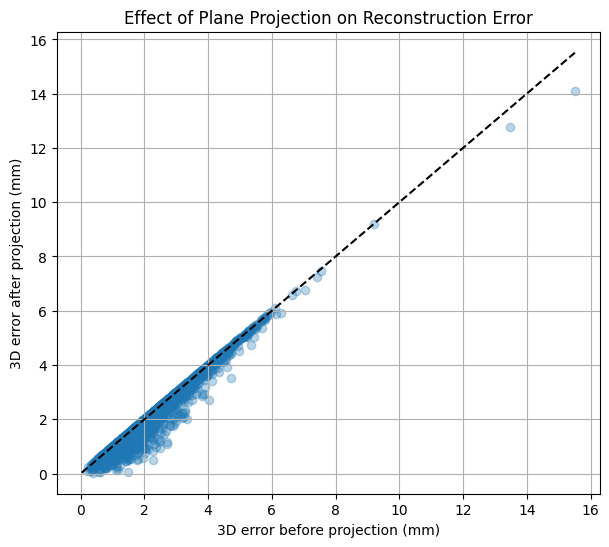

In [66]:
plt.figure(figsize=(7, 6))
plt.scatter(original_distance_PR, projected_distance_PR, alpha=0.3)

lo = min(original_distance_PR.min(), projected_distance_PR.min())
hi = max(original_distance_PR.max(), projected_distance_PR.max())
plt.plot([lo, hi], [lo, hi], color="black", linestyle="--")

plt.xlabel("3D error before projection (mm)")
plt.ylabel("3D error after projection (mm)")
plt.title("Effect of Plane Projection on Reconstruction Error")
plt.grid()
plt.show()

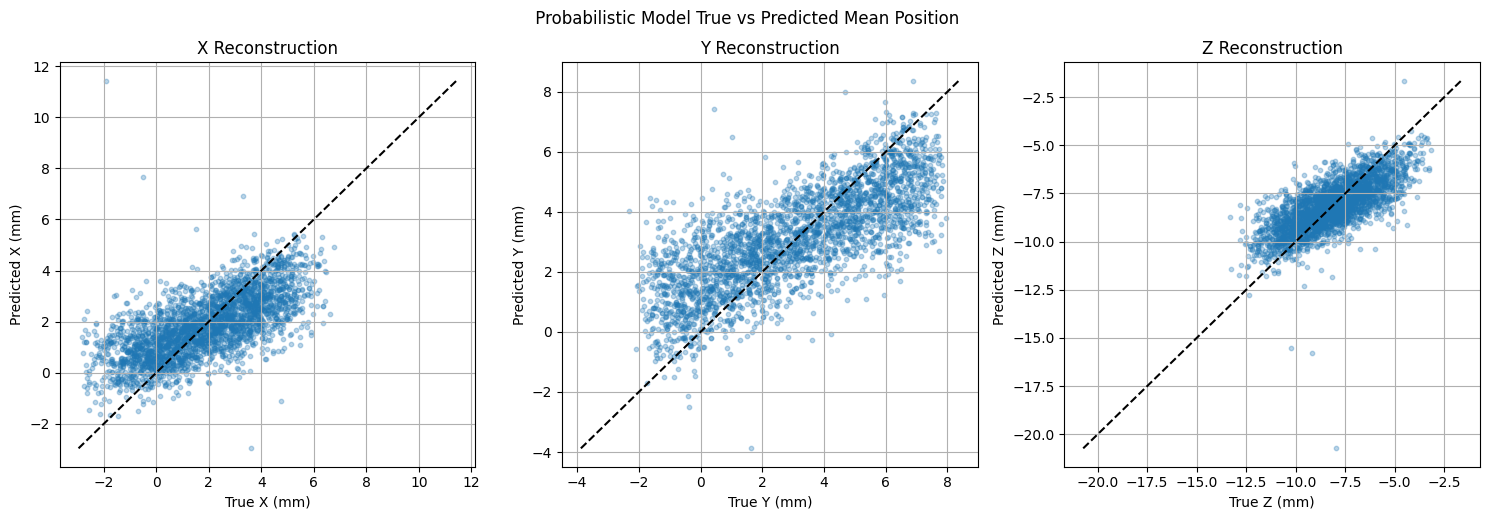

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):
    ax.scatter(y_test_PR[:, i], mu_mm_PR[:, i], alpha=0.3, s=10)
    lo = min(y_test_PR[:, i].min(), mu_mm_PR[:, i].min())
    hi = max(y_test_PR[:, i].max(), mu_mm_PR[:, i].max())
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel(f"Predicted {coords[i]} (mm)")
    ax.set_title(f"{coords[i]} Reconstruction")
    ax.grid(True)

plt.tight_layout()
plt.suptitle(" Probabilistic Model True vs Predicted Mean Position", y=1.03)
plt.show()

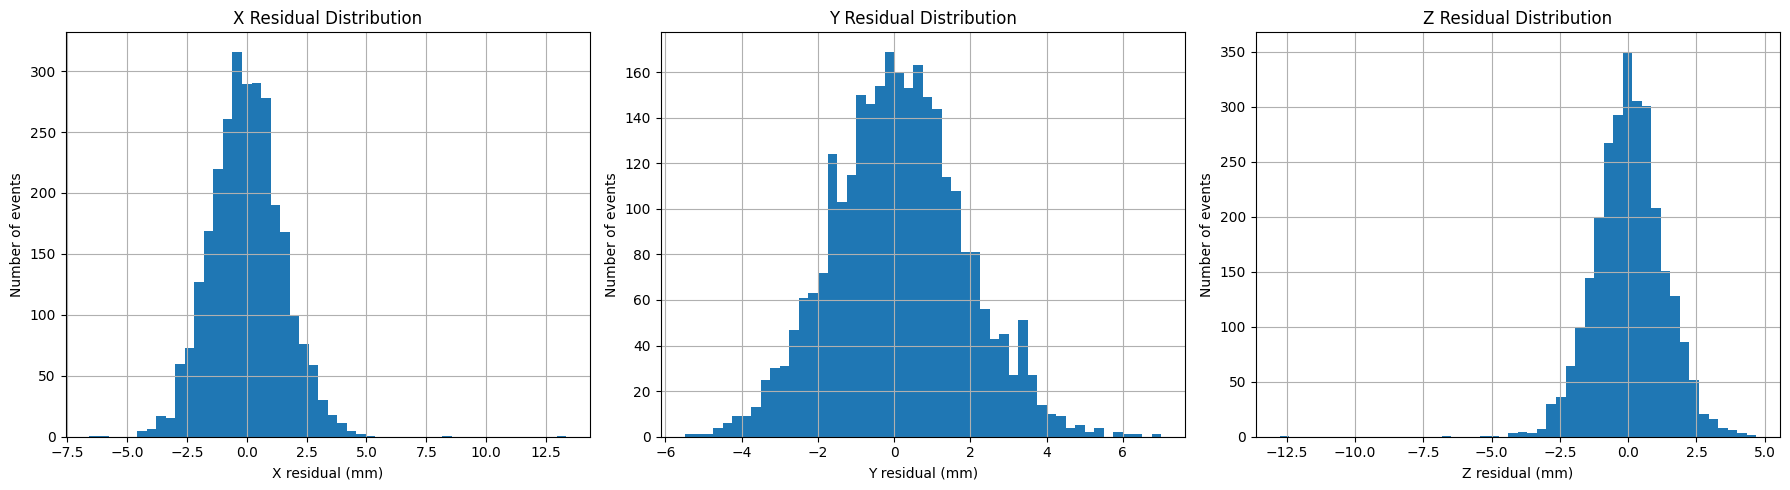

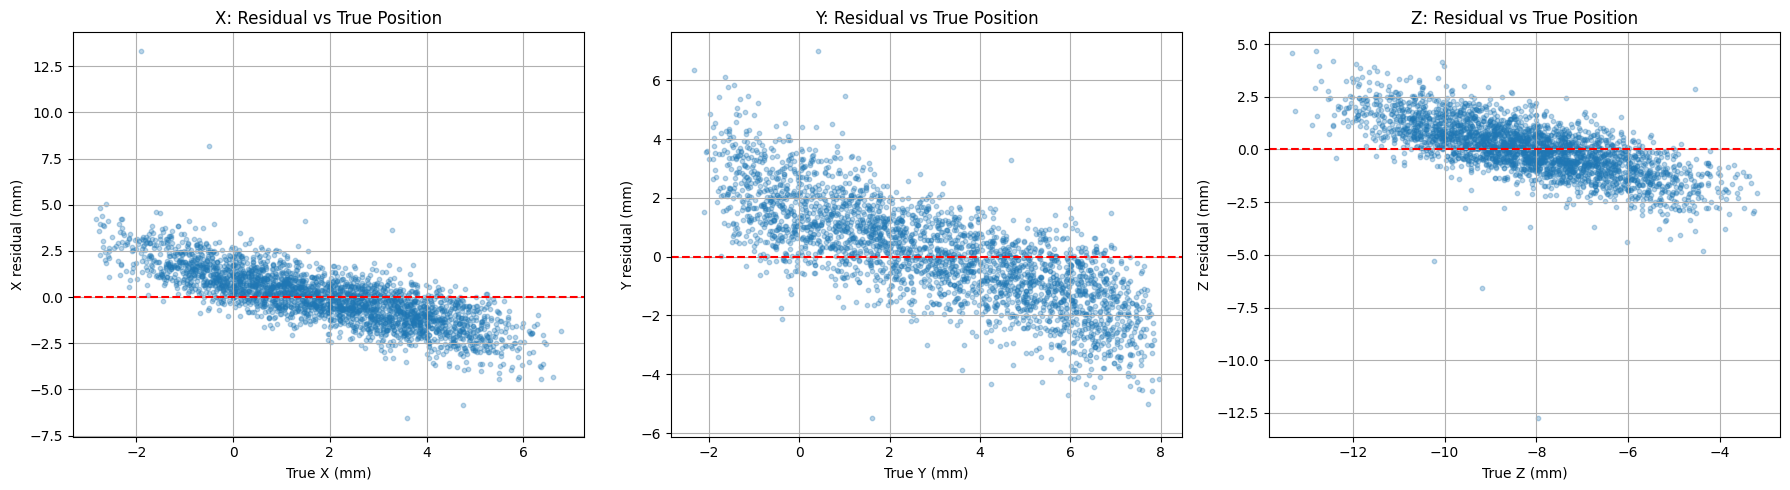

In [68]:
residuals_PR = mu_mm_PR - y_test_PR

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.hist(residuals_PR[:, i], bins=50)
    ax.set_xlabel(f"{coords[i]} residual (mm)")
    ax.set_ylabel("Number of events")
    ax.set_title(f"{coords[i]} Residual Distribution")
    ax.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.scatter(y_test_PR[:, i], residuals_PR[:, i], alpha=0.3, s=10)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel(f"{coords[i]} residual (mm)")
    ax.set_title(f"{coords[i]}: Residual vs True Position")
    ax.grid(True)
plt.tight_layout()
plt.show()

### 2.10 Uncertainty analysis

Uncertainty-error correlation: 0.24088050494287397


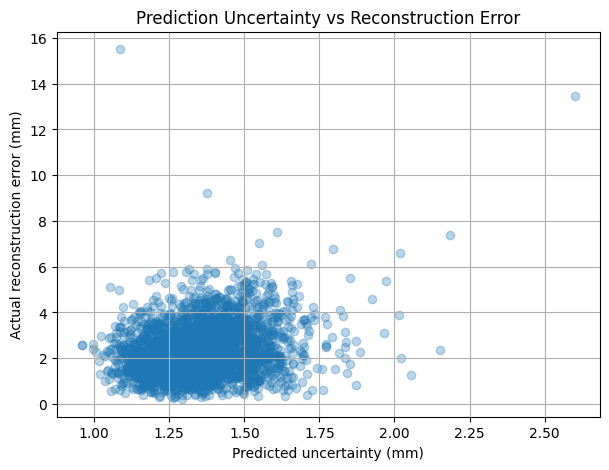

In [69]:
mean_sigma_PR = np.mean(sigma_mm_PR, axis=1)

correlation_PR = np.corrcoef(mean_sigma_PR, original_distance_PR)[0, 1]
print("Uncertainty-error correlation:", correlation_PR)

plt.figure(figsize=(7, 5))
plt.scatter(mean_sigma_PR, original_distance_PR, alpha=0.3)
plt.xlabel("Predicted uncertainty (mm)")
plt.ylabel("Actual reconstruction error (mm)")
plt.title("Prediction Uncertainty vs Reconstruction Error")
plt.grid()
plt.show()

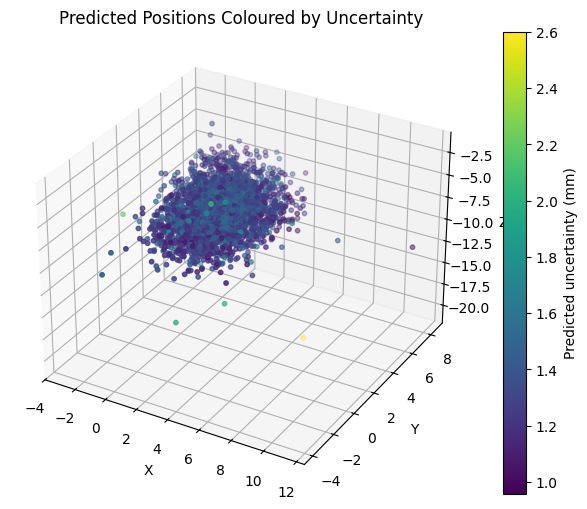

In [70]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(mu_mm_PR[:, 0], mu_mm_PR[:, 1], mu_mm_PR[:, 2], c=mean_sigma_PR, s=10)
plt.colorbar(sc, label="Predicted uncertainty (mm)")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Predicted Positions Coloured by Uncertainty")
plt.show()

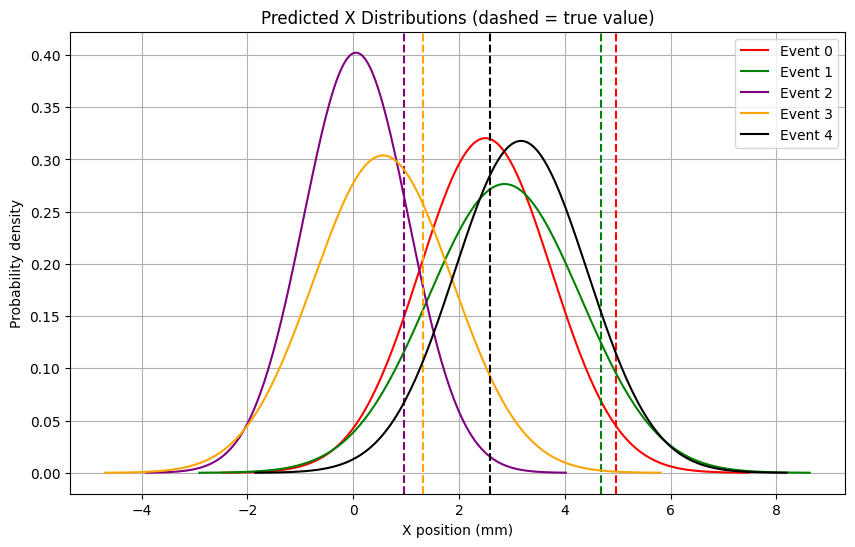

In [71]:
plt.figure(figsize=(10, 6))

events = [0, 1, 2, 3, 4]
colours = ["red", "green", "purple", "orange", "black"]

for event, colour in zip(events, colours):
    x = np.linspace(
        mu_mm_PR[event, 0] - 4 * sigma_mm_PR[event, 0],
        mu_mm_PR[event, 0] + 4 * sigma_mm_PR[event, 0],
        200,
    )
    pdf = (
        1 / (sigma_mm_PR[event, 0] * np.sqrt(2 * np.pi))
        * np.exp(-(x - mu_mm_PR[event, 0]) ** 2 / (2 * sigma_mm_PR[event, 0] ** 2))
    )
    plt.plot(x, pdf, color=colour, label=f"Event {event}")
    plt.axvline(y_test_PR[event, 0], color=colour, linestyle="--")

plt.xlabel("X position (mm)")
plt.ylabel("Probability density")
plt.title("Predicted X Distributions (dashed = true value)")
plt.legend()
plt.grid()
plt.show()

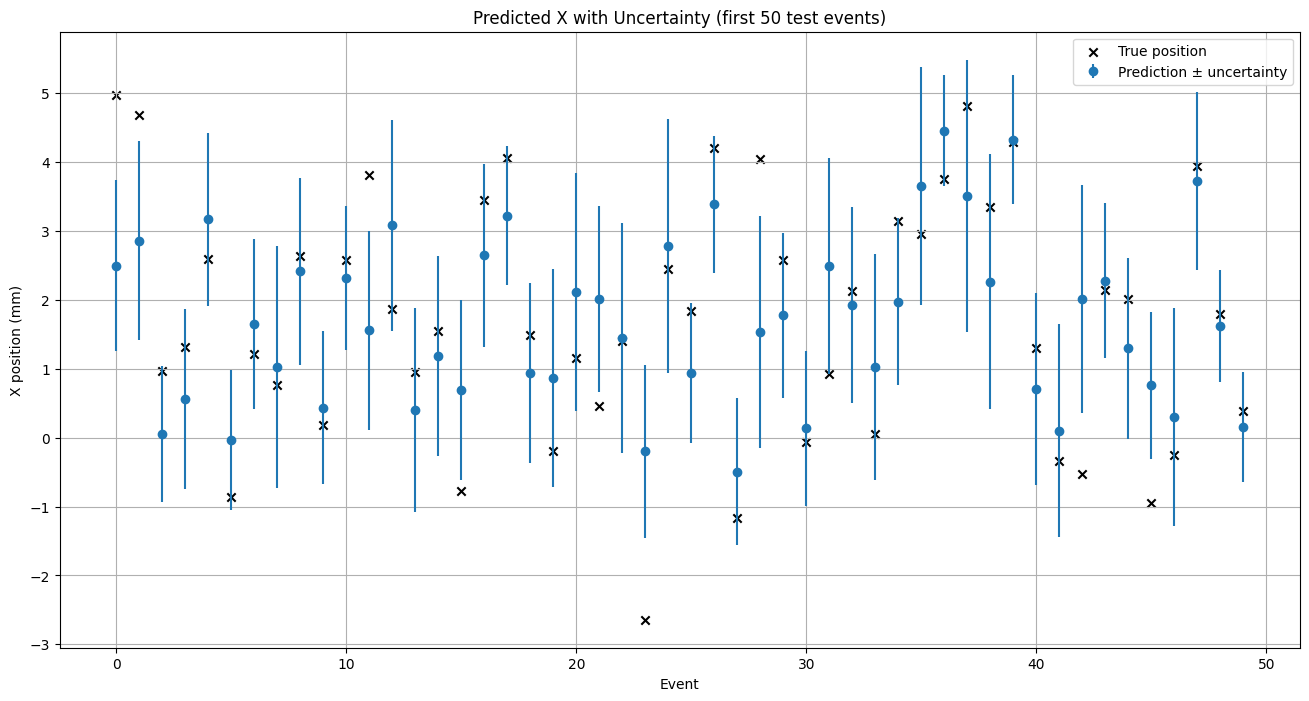

In [72]:
idx = np.arange(50)

plt.figure(figsize=(16, 8))
plt.errorbar(idx, mu_mm_PR[:50, 0], yerr=sigma_mm_PR[:50, 0], fmt="o", label="Prediction ± uncertainty")
plt.scatter(idx, y_test_PR[:50, 0], marker="x", color="black", label="True position")

plt.xlabel("Event")
plt.ylabel("X position (mm)")
plt.title("Predicted X with Uncertainty (first 50 test events)")
plt.legend()
plt.grid()
plt.show()

In [75]:
# Naive baseline: always predict the mean training position
mean_position_PR = np.mean(y_train_PR, axis=0)
baseline_prediction_PR = np.tile(mean_position_PR, (len(y_test_PR), 1))


prediction_PR = mu_mm_PR_projected

baseline_mse_PR = mean_squared_error(y_test_PR, baseline_prediction_PR)
cnn_mse_PR = mean_squared_error(y_test_PR, prediction_PR)

baseline_mae_PR = mean_absolute_error(y_test_PR, baseline_prediction_PR)
cnn_mae_PR = mean_absolute_error(y_test_PR, prediction_PR)

print("Baseline MSE:", baseline_mse_PR, " | CNN MSE:", cnn_mse_PR)
print("Baseline MAE:", baseline_mae_PR, " | CNN MAE:", cnn_mae_PR)
print ('Overall Improvement', (baseline_mae_PR - cnn_mae_PR) / baseline_mae_PR * 100, '%')
print("\nPer-axis MAE (baseline vs CNN):")
for i, coord in enumerate(["X", "Y", "Z"]):
    baseline_i = mean_absolute_error(y_test_PR[:, i], baseline_prediction_PR[:, i])
    cnn_i = mean_absolute_error(y_test_PR[:, i], prediction_PR[:, i])
    print(f"  {coord}: baseline={baseline_i:.2f} mm, CNN={cnn_i:.2f} mm")

r2_overall_PR = r2_score(y_test_PR, prediction_PR)
r2_axes_PR = [r2_score(y_test_PR[:, i], prediction_PR[:, i]) for i in range(3)]

print("\nOverall R2:", r2_overall_PR)
print("Per-axis R2 (X, Y, Z):", r2_axes_PR)

Baseline MSE: 4.760537624359131  | CNN MSE: 2.091191291809082
Baseline MAE: 1.8187737464904785  | CNN MAE: 1.1025820970535278
Overall Improvement 39.37772088578473 %

Per-axis MAE (baseline vs CNN):
  X: baseline=1.69 mm, CNN=1.08 mm
  Y: baseline=2.26 mm, CNN=1.25 mm
  Z: baseline=1.50 mm, CNN=0.98 mm

Overall R2: 0.5468605160713196
Per-axis R2 (X, Y, Z): [0.5023889541625977, 0.6120154857635498, 0.5261770486831665]


### 2.10 Summary

In [76]:
r2_overall_PR = r2_score(y_test_PR, mu_mm_PR_projected)

results_PR = {
    "model": "Model PR (Probabilistic CNN, plane-projected)",
    "mae_x": mean_absolute_error(y_test_PR[:, 0], mu_mm_PR_projected[:, 0]),
    "mae_y": mean_absolute_error(y_test_PR[:, 1], mu_mm_PR_projected[:, 1]),
    "mae_z": mean_absolute_error(y_test_PR[:, 2], mu_mm_PR_projected[:, 2]),
    "mae_overall": mae_projected_PR,
    "mean_3d_error_mm": np.mean(projected_distance_PR),
    "median_3d_error_mm": np.median(projected_distance_PR),
    "r2_overall": r2_overall_PR,
    "mean_uncertainty_mm": np.mean(mean_sigma_PR),
    "uncertainty_error_correlation": correlation_PR,
    'improvement over naive baseline (%)': (baseline_mae_PR - mae_projected_PR) / baseline_mae_PR * 100,
}

results_PR

{'model': 'Model PR (Probabilistic CNN, plane-projected)',
 'mae_x': 1.0833719968795776,
 'mae_y': 1.246903419494629,
 'mae_z': 0.9774712920188904,
 'mae_overall': 1.1025820970535278,
 'mean_3d_error_mm': np.float32(2.2143056),
 'median_3d_error_mm': np.float32(2.0611315),
 'r2_overall': 0.5468605160713196,
 'mean_uncertainty_mm': np.float64(1.3559591181572557),
 'uncertainty_error_correlation': np.float64(0.24088050494287397),
 'improvement over naive baseline (%)': 39.37772088578473}

comparison_rows = [
    {
        "Model": "A: Deterministic CNN",
        "MAE X (mm)": results_DE["mae_x"],
        "MAE Y (mm)": results_DE["mae_y"],
        "MAE Z (mm)": results_DE["mae_z"],
        "Overall MAE (mm)": results_DE["mae_overall"],
        "Mean 3D error (mm)": results_DE["mean_3d_error_mm"],
        "Median 3D error (mm)": results_DE["median_3d_error_mm"],
        "R2": results_DE["r2_overall"],
    },
    {
        "Model": "PR: Probabilistic CNN (plane-projected)",
        "MAE X (mm)": results_PR["mae_x"],
        "MAE Y (mm)": results_PR["mae_y"],
        "MAE Z (mm)": results_PR["mae_z"],
        "Overall MAE (mm)": results_PR["mae_overall"],
        "Mean 3D error (mm)": results_PR["mean_3d_error_mm"],
        "Median 3D error (mm)": results_PR["median_3d_error_mm"],
        "R2": results_PR["r2_overall"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df

In [78]:
comparison_rows = [
    {
        "Model": "A: Deterministic CNN",
        "MAE X (mm)": results_DE["mae_x"],
        "MAE Y (mm)": results_DE["mae_y"],
        "MAE Z (mm)": results_DE["mae_z"],
        "Overall MAE (mm)": results_DE["mae_overall"],
        "Mean 3D error (mm)": results_DE["mean_3d_error_mm"],
        "Median 3D error (mm)": results_DE["median_3d_error_mm"],
        "R2": results_DE["r2_overall"],
    },
    {
        "Model": "PR: Probabilistic CNN (plane-projected)",
        "MAE X (mm)": results_PR["mae_x"],
        "MAE Y (mm)": results_PR["mae_y"],
        "MAE Z (mm)": results_PR["mae_z"],
        "Overall MAE (mm)": results_PR["mae_overall"],
        "Mean 3D error (mm)": results_PR["mean_3d_error_mm"],
        "Median 3D error (mm)": results_PR["median_3d_error_mm"],
        "R2": results_PR["r2_overall"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df

,MAE X (mm),MAE Y (mm),MAE Z (mm),Overall MAE (mm),Mean 3D error (mm),Median 3D error (mm),R2
Model,,,,,,,
A: Deterministic CNN,1.200168,1.539749,1.109589,1.283168,2.572050,2.423757,0.435798
PR: Probabilistic CNN (plane-projected),1.083372,1.246903,0.977471,1.102582,2.214306,2.061131,0.546861


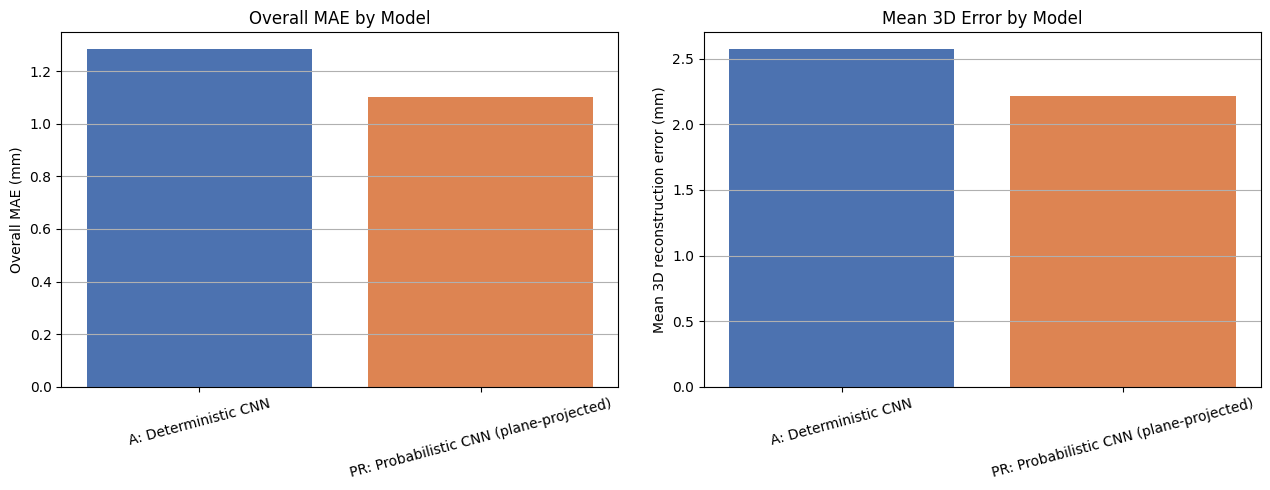

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = comparison_df.index.tolist()

axes[0].bar(models, comparison_df["Overall MAE (mm)"], color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("Overall MAE (mm)")
axes[0].set_title("Overall MAE by Model")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y")

axes[1].bar(models, comparison_df["Mean 3D error (mm)"], color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Mean 3D reconstruction error (mm)")
axes[1].set_title("Mean 3D Error by Model")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

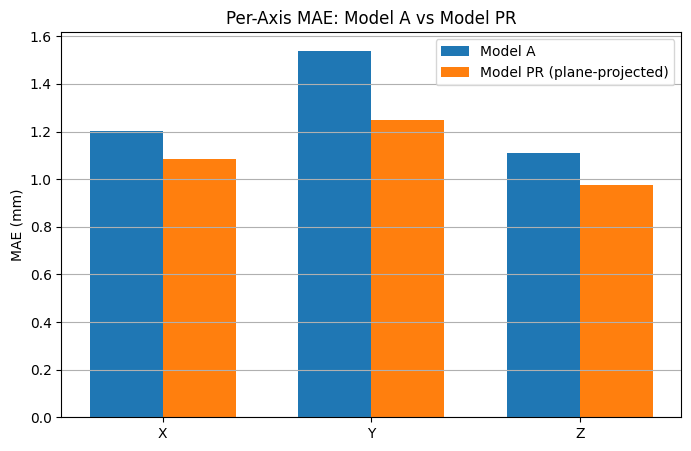

In [80]:
# Per-axis MAE side by side
axis_labels = ["X", "Y", "Z"]
mae_DE_axes = [results_DE["mae_x"], results_DE["mae_y"], results_DE["mae_z"]]
mae_PR_axes = [results_PR["mae_x"], results_PR["mae_y"], results_PR["mae_z"]]

x_pos = np.arange(len(axis_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x_pos - width / 2, mae_DE_axes, width, label="Model A")
plt.bar(x_pos + width / 2, mae_PR_axes, width, label="Model PR (plane-projected)")

plt.xticks(x_pos, axis_labels)
plt.ylabel("MAE (mm)")
plt.title("Per-Axis MAE: Model A vs Model PR")
plt.legend()
plt.grid(axis="y")
plt.show()

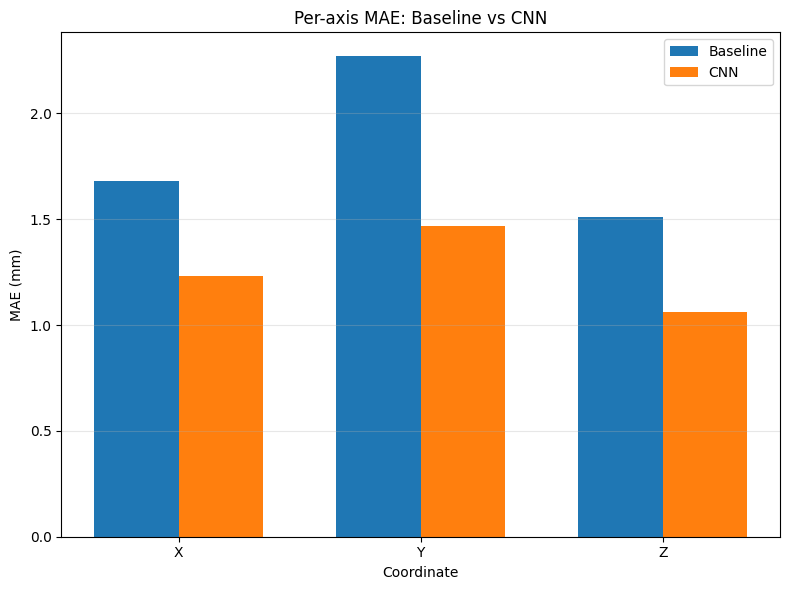

In [81]:
import numpy as np
import matplotlib.pyplot as plt

coordinates = ["X", "Y", "Z"]

baseline_mae = [1.68, 2.27, 1.51]
cnn_mae = [1.23, 1.47, 1.06]

x = np.arange(len(coordinates))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(
    x - width/2,
    baseline_mae,
    width,
    label="Baseline"
)

plt.bar(
    x + width/2,
    cnn_mae,
    width,
    label="CNN"
)

plt.xticks(x, coordinates)
plt.ylabel("MAE (mm)")
plt.xlabel("Coordinate")
plt.title("Per-axis MAE: Baseline vs CNN")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

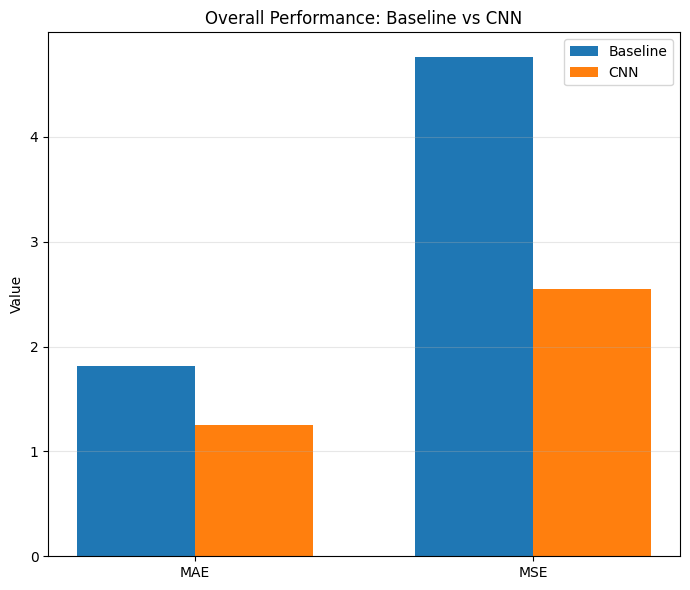

In [82]:
metrics = ["MAE", "MSE"]

baseline_values = [
    1.818593144416809,
    4.758697032928467
]

cnn_values = [
    1.2507377862930298,
    2.546839714050293
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 6))

plt.bar(
    x - width/2,
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    x + width/2,
    cnn_values,
    width,
    label="CNN"
)

plt.xticks(x, metrics)
plt.ylabel("Value")
plt.title("Overall Performance: Baseline vs CNN")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

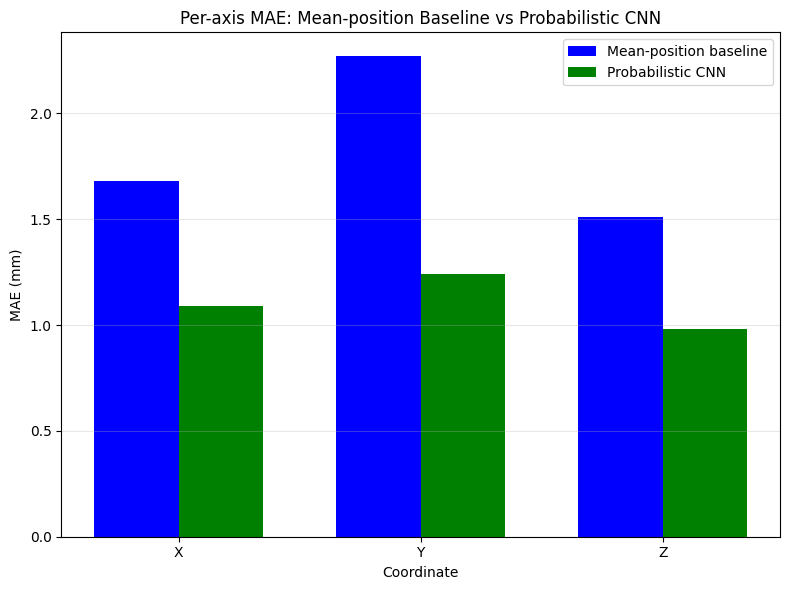

In [83]:
import numpy as np
import matplotlib.pyplot as plt

coordinates = ["X", "Y", "Z"]

baseline_mae = [1.68, 2.27, 1.51]

cnn_PR_mae = [
    1.0887095928192139,
    1.2419756650924683,
    0.9829121828079224
]

x = np.arange(len(coordinates))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(
    x - width/2,
    baseline_mae,
    width,
    label="Mean-position baseline", color= 'blue'
)

plt.bar(
    x + width/2,
    cnn_PR_mae,
    width,
    label="Probabilistic CNN", color = 'green'
)

plt.xticks(x, coordinates)
plt.ylabel("MAE (mm)")
plt.xlabel("Coordinate")
plt.title("Per-axis MAE: Mean-position Baseline vs Probabilistic CNN")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

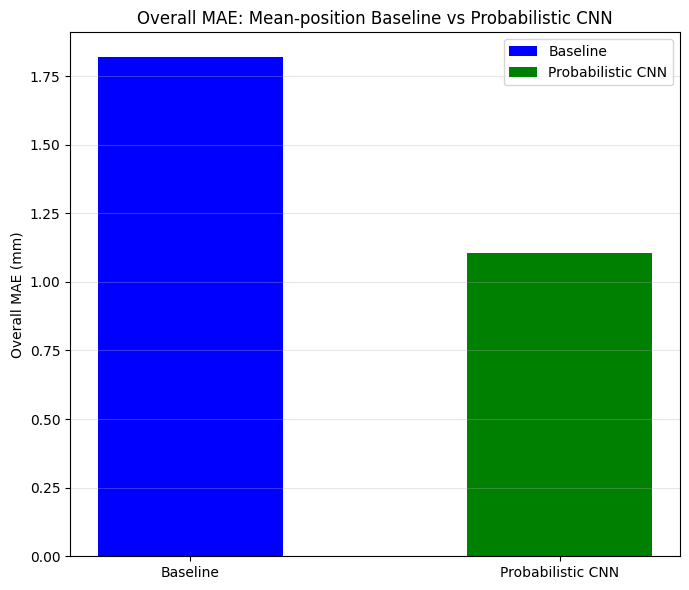

In [84]:
baseline_values = 1.818593144416809
cnn_values = 1.1045327186584473

metrics_labels = ["Baseline", "Probabilistic CNN"]
mae_values = [baseline_values, cnn_values]
x_pos = np.arange(len(metrics_labels))
width = 0.5

plt.figure(figsize=(7, 6))

plt.bar(
    x_pos[0],
    mae_values[0],
    width,
    label="Baseline", color= 'blue'
)

plt.bar(
    x_pos[1],
    mae_values[1],
    width,
    label="Probabilistic CNN", color = 'green'
)

plt.xticks(x_pos, metrics_labels)
plt.ylabel("Overall MAE (mm)")
plt.title("Overall MAE: Mean-position Baseline vs Probabilistic CNN")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

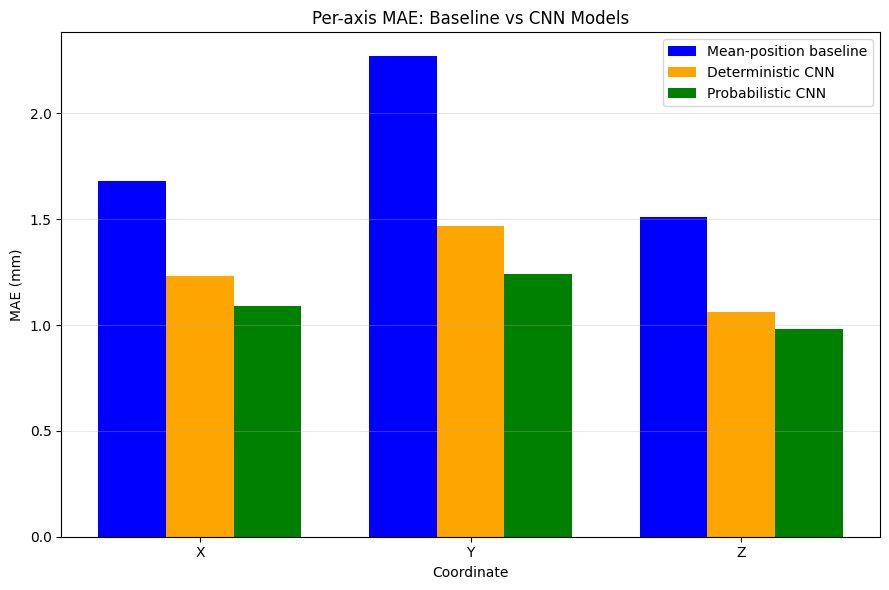

In [52]:
import numpy as np
import matplotlib.pyplot as plt

coordinates = ["X", "Y", "Z"]

baseline_mae = [1.68, 2.27, 1.51]

deterministic_cnn_mae = [
    1.23,
    1.47,
    1.06
]

probabilistic_cnn_mae = [
    1.0887095928192139,
    1.2419756650924683,
    0.9829121828079224
]

x = np.arange(len(coordinates))
width = 0.25

plt.figure(figsize=(9, 6))

plt.bar(
    x - width,
    baseline_mae,
    width,
    label="Mean-position baseline",
    color="blue"
)

plt.bar(
    x,
    deterministic_cnn_mae,
    width,
    label="Deterministic CNN",
    color="orange"
)

plt.bar(
    x + width,
    probabilistic_cnn_mae,
    width,
    label="Probabilistic CNN",
    color="green"
)

plt.xticks(x, coordinates)
plt.ylabel("MAE (mm)")
plt.xlabel("Coordinate")
plt.title("Per-axis MAE: Baseline vs CNN Models")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

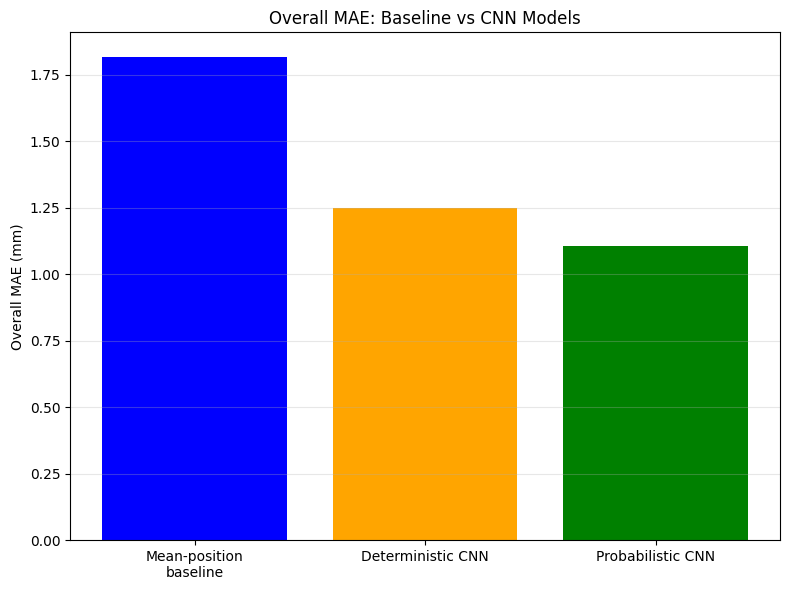

In [53]:
models = [
    "Mean-position\nbaseline",
    "Deterministic CNN",
    "Probabilistic CNN"
]

overall_mae = [
    1.818593144416809,
    1.2507377862930298,
    1.1045327186584473
]

plt.figure(figsize=(8, 6))

plt.bar(
    models,
    overall_mae,
    color=["blue", "orange", "green"]
)

plt.ylabel("Overall MAE (mm)")
plt.title("Overall MAE: Baseline vs CNN Models")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()